# MATH 5010 Computer Lab for Sections 18–19

## Bayesian Inference II and ANOVA II — Full Solutions

**Course:** MATH 5010 Foundations of Statistical Theory & Probability  
**Level:** Master's students  
**Software:** Python

This lab continues the inference part of the course.  It is designed as a complete worked computer lab with solutions.

### Main goals

By the end of this lab, students should be able to:

1. Compute Bayesian posterior distributions for common conjugate models.
2. Compute Bayesian credible intervals and posterior probabilities.
3. Use posterior predictive distributions to check a model.
4. Implement a basic Gibbs sampler for a normal model with unknown mean and variance.
5. Fit two-way ANOVA models with and without interaction.
6. Compute linear contrasts, confidence intervals, and multiple comparisons.
7. Use simulation and permutation ideas to understand ANOVA assumptions.


## 0. Setup

Run the cell below first.  We use only standard scientific Python packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import betaln, gammaln

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(5010)

pd.set_option("display.precision", 4)


# Section 18. Bayesian Inference II

Bayesian inference combines a **prior distribution** and a **likelihood** to produce a **posterior distribution**:

$$
\pi(\theta \mid x) \propto L(\theta; x)\pi(\theta).
$$

In this section, we focus on computation, interpretation, and simulation.


## Exercise 1. Normal mean with known variance

Suppose

$$
X_1,\ldots,X_n \mid \mu \overset{iid}{\sim} N(\mu,\sigma^2),
$$

where $\sigma^2$ is known.  Use the conjugate prior

$$
\mu \sim N(m_0,s_0^2).
$$

### Tasks

1. Simulate data from $N(\mu,\sigma^2)$.
2. Derive the posterior distribution of $\mu$.
3. Compute the posterior mean and a 95% credible interval.
4. Compare the posterior mean with the sample mean.

### Solution formula

The posterior is normal:

$$
\mu \mid x_1,\ldots,x_n \sim N(m_n,s_n^2),
$$

where

$$
\frac{1}{s_n^2}=\frac{1}{s_0^2}+\frac{n}{\sigma^2},
$$

and

$$
m_n=s_n^2\left(\frac{m_0}{s_0^2}+\frac{n\bar{x}}{\sigma^2}\right).
$$


In [2]:
# True data-generating parameters
mu_true = 72
sigma = 8
n = 25

# Prior parameters
m0 = 65
s0 = 10

# Simulate data
x = np.random.normal(loc=mu_true, scale=sigma, size=n)
xbar = x.mean()

# Posterior calculation
post_var = 1 / (1/s0**2 + n/sigma**2)
post_sd = np.sqrt(post_var)
post_mean = post_var * (m0/s0**2 + n*xbar/sigma**2)

ci_low, ci_high = stats.norm.ppf([0.025, 0.975], loc=post_mean, scale=post_sd)

result = pd.DataFrame({
    "quantity": ["true mu", "sample mean", "prior mean", "posterior mean", "posterior sd", "95% credible interval low", "95% credible interval high"],
    "value": [mu_true, xbar, m0, post_mean, post_sd, ci_low, ci_high]
})
result


,quantity,value
0,true mu,72.0000
1,sample mean,72.0290
2,prior mean,65.0000
3,posterior mean,71.8535
4,posterior sd,1.5799
5,95% credible interval low,68.7570
6,95% credible interval high,74.9501


### Interpretation

The posterior mean is a weighted average of the prior mean and the sample mean.  Since the data contain $n=25$ observations and the prior standard deviation is moderately large, the posterior mean is usually closer to the sample mean than to the prior mean.


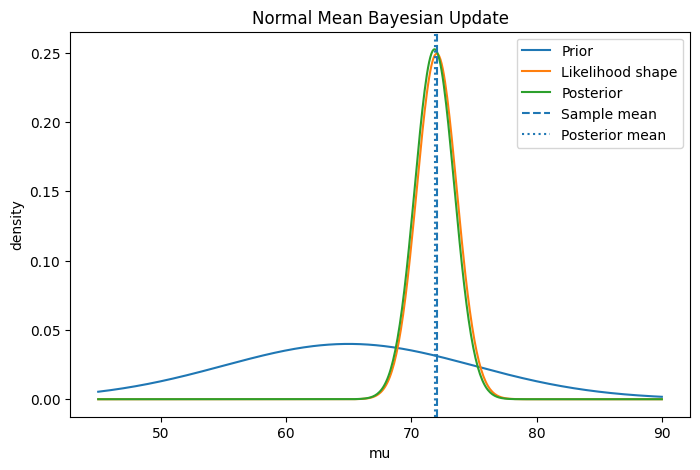

In [3]:
# Plot prior, likelihood-based estimate, and posterior
mu_grid = np.linspace(45, 90, 500)
prior_pdf = stats.norm.pdf(mu_grid, loc=m0, scale=s0)
posterior_pdf = stats.norm.pdf(mu_grid, loc=post_mean, scale=post_sd)
# Distribution of sample mean under fixed mu has standard error sigma/sqrt(n)
likelihood_shape = stats.norm.pdf(mu_grid, loc=xbar, scale=sigma/np.sqrt(n))

plt.figure(figsize=(8, 5))
plt.plot(mu_grid, prior_pdf, label="Prior")
plt.plot(mu_grid, likelihood_shape, label="Likelihood shape")
plt.plot(mu_grid, posterior_pdf, label="Posterior")
plt.axvline(xbar, linestyle="--", label="Sample mean")
plt.axvline(post_mean, linestyle=":", label="Posterior mean")
plt.xlabel("mu")
plt.ylabel("density")
plt.title("Normal Mean Bayesian Update")
plt.legend()
plt.show()


## Exercise 2. Prior sensitivity

Repeat the normal-mean posterior calculation using three priors:

1. Weak prior: $\mu \sim N(65, 30^2)$.
2. Moderate prior: $\mu \sim N(65, 10^2)$.
3. Strong prior: $\mu \sim N(65, 2^2)$.

### Task

Compare the posterior means and posterior intervals.


In [4]:
def normal_mean_posterior_known_sigma(x, sigma, m0, s0):
    n = len(x)
    xbar = np.mean(x)
    post_var = 1 / (1/s0**2 + n/sigma**2)
    post_sd = np.sqrt(post_var)
    post_mean = post_var * (m0/s0**2 + n*xbar/sigma**2)
    ci = stats.norm.ppf([0.025, 0.975], loc=post_mean, scale=post_sd)
    return post_mean, post_sd, ci[0], ci[1]

priors = [
    ("weak", 65, 30),
    ("moderate", 65, 10),
    ("strong", 65, 2),
]

rows = []
for name, m0_i, s0_i in priors:
    pm, psd, lo, hi = normal_mean_posterior_known_sigma(x, sigma, m0_i, s0_i)
    rows.append({
        "prior": name,
        "prior_mean": m0_i,
        "prior_sd": s0_i,
        "posterior_mean": pm,
        "posterior_sd": psd,
        "CI_low": lo,
        "CI_high": hi,
    })

pd.DataFrame(rows)


,prior,prior_mean,prior_sd,posterior_mean,posterior_sd,CI_low,CI_high
0,weak,65,30,72.0090,1.5977,68.8776,75.1405
1,moderate,65,10,71.8535,1.5799,68.7570,74.9501
2,strong,65,2,69.2860,1.2494,66.8372,71.7347


### Interpretation

A weak prior lets the data dominate.  A strong prior pulls the posterior mean toward the prior mean and can make the credible interval narrower.  This is useful when prior information is real, but dangerous if the prior is too strong and poorly chosen.


## Exercise 3. Beta-Binomial A/B test

An A/B test measures conversion rates for two versions of a webpage.

- Version A: $x_A=54$ conversions out of $n_A=400$ visitors.
- Version B: $x_B=72$ conversions out of $n_B=420$ visitors.

Assume independent priors

$$
p_A \sim \operatorname{Beta}(1,1), \qquad p_B \sim \operatorname{Beta}(1,1).
$$

### Tasks

1. Find the posterior distributions of $p_A$ and $p_B$.
2. Compute posterior means and 95% credible intervals.
3. Estimate $P(p_B>p_A \mid \text{data})$ using Monte Carlo simulation.
4. Estimate the posterior distribution of the lift $p_B-p_A$.


In [5]:
# Observed A/B test data
n_A, x_A = 400, 54
n_B, x_B = 420, 72

# Beta(1, 1) priors
a0, b0 = 1, 1

# Posterior parameters
post_A = (a0 + x_A, b0 + n_A - x_A)
post_B = (a0 + x_B, b0 + n_B - x_B)

summary_rows = []
for label, pars in [("A", post_A), ("B", post_B)]:
    a, b = pars
    mean = a / (a + b)
    ci = stats.beta.ppf([0.025, 0.975], a, b)
    summary_rows.append({
        "version": label,
        "posterior": f"Beta({a}, {b})",
        "posterior_mean": mean,
        "CI_low": ci[0],
        "CI_high": ci[1],
    })

pd.DataFrame(summary_rows)


,version,posterior,posterior_mean,CI_low,CI_high
0,A,"Beta(55, 347)",0.1368,0.1050,0.1720
1,B,"Beta(73, 349)",0.1730,0.1384,0.2105


In [6]:
# Monte Carlo posterior comparison
M = 200_000
pA_samples = np.random.beta(post_A[0], post_A[1], size=M)
pB_samples = np.random.beta(post_B[0], post_B[1], size=M)
lift_samples = pB_samples - pA_samples

prob_B_better = np.mean(pB_samples > pA_samples)
lift_ci = np.quantile(lift_samples, [0.025, 0.5, 0.975])

pd.DataFrame({
    "quantity": ["P(p_B > p_A | data)", "lift 2.5%", "lift median", "lift 97.5%"],
    "value": [prob_B_better, lift_ci[0], lift_ci[1], lift_ci[2]]
})


,quantity,value
0,P(p_B > p_A | data),0.9259
1,lift 2.5%,-0.0130
2,lift median,0.0362
3,lift 97.5%,0.0852


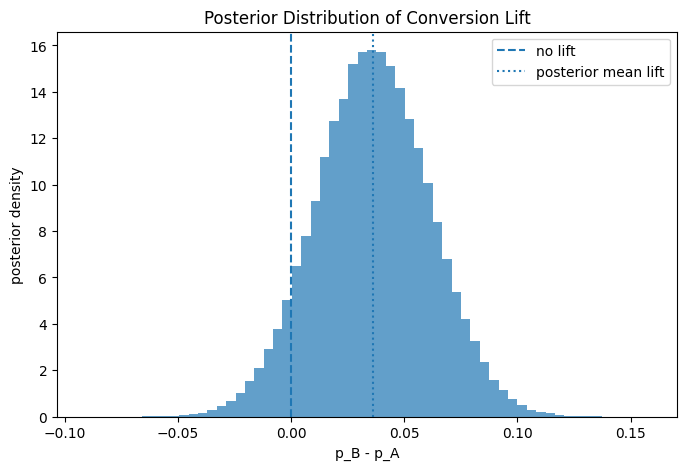

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(lift_samples, bins=60, density=True, alpha=0.7)
plt.axvline(0, linestyle="--", label="no lift")
plt.axvline(np.mean(lift_samples), linestyle=":", label="posterior mean lift")
plt.xlabel("p_B - p_A")
plt.ylabel("posterior density")
plt.title("Posterior Distribution of Conversion Lift")
plt.legend()
plt.show()


### Interpretation

The posterior probability $P(p_B>p_A\mid \text{data})$ directly answers a decision question.  Unlike a classical $p$-value, it is a probability statement about the unknown conversion rates after conditioning on the observed data and the prior.


## Exercise 4. Posterior predictive distribution for Poisson-Gamma model

Suppose customer arrivals per hour follow

$$
X_i \mid \lambda \overset{iid}{\sim} \operatorname{Poisson}(\lambda).
$$

Use the prior

$$
\lambda \sim \operatorname{Gamma}(a,b),
$$

where $b$ is the **rate** parameter.

Data from 12 hours are:

$$
7, 5, 8, 6, 9, 4, 5, 7, 6, 8, 7, 10.
$$

### Tasks

1. Find the posterior distribution of $\lambda$.
2. Compute the posterior mean and a 95% credible interval.
3. Simulate the posterior predictive distribution for a future hour.
4. Compute $P(X_{new} \ge 10 \mid \text{data})$.


In [8]:
counts = np.array([7, 5, 8, 6, 9, 4, 5, 7, 6, 8, 7, 10])
n = len(counts)
S = counts.sum()

# Prior Gamma(a, b), shape-rate parameterization
a, b = 2, 1

post_shape = a + S
post_rate = b + n

post_mean_lambda = post_shape / post_rate
post_ci_lambda = stats.gamma.ppf([0.025, 0.975], a=post_shape, scale=1/post_rate)

pd.DataFrame({
    "quantity": ["n", "sum counts", "posterior shape", "posterior rate", "posterior mean lambda", "CI low", "CI high"],
    "value": [n, S, post_shape, post_rate, post_mean_lambda, post_ci_lambda[0], post_ci_lambda[1]]
})


,quantity,value
0,n,12.0000
1,sum counts,82.0000
2,posterior shape,84.0000
3,posterior rate,13.0000
4,posterior mean lambda,6.4615
5,CI low,5.1540
6,CI high,7.9147


In [9]:
# Posterior predictive simulation
M = 200_000
lambda_samples = np.random.gamma(shape=post_shape, scale=1/post_rate, size=M)
xnew_samples = np.random.poisson(lambda_samples)

prob_future_ge_10 = np.mean(xnew_samples >= 10)

pred_summary = pd.DataFrame({
    "quantity": ["posterior predictive mean", "posterior predictive sd", "P(X_new >= 10 | data)", "predictive 2.5%", "predictive 97.5%"],
    "value": [xnew_samples.mean(), xnew_samples.std(), prob_future_ge_10, np.quantile(xnew_samples, 0.025), np.quantile(xnew_samples, 0.975)]
})
pred_summary


,quantity,value
0,posterior predictive mean,6.4521
1,posterior predictive sd,2.6368
2,P(X_new >= 10 | data),0.1272
3,predictive 2.5%,2.0000
4,predictive 97.5%,12.0000


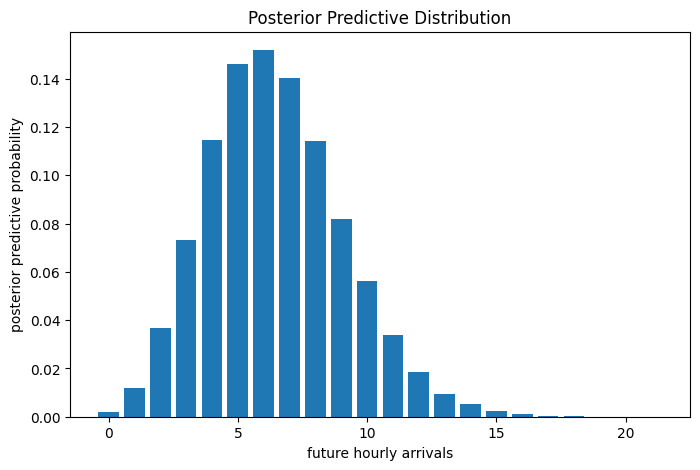

In [10]:
vals, freqs = np.unique(xnew_samples, return_counts=True)
probs = freqs / freqs.sum()

plt.figure(figsize=(8, 5))
plt.bar(vals, probs)
plt.xlabel("future hourly arrivals")
plt.ylabel("posterior predictive probability")
plt.title("Posterior Predictive Distribution")
plt.show()


### Interpretation

The posterior distribution describes uncertainty about $\lambda$.  The posterior predictive distribution describes uncertainty about a future count.  It includes both parameter uncertainty and Poisson sampling variability.


## Exercise 5. Gibbs sampler for a normal model with unknown mean and variance

Suppose

$$
X_1,\ldots,X_n \mid \mu,\sigma^2 \overset{iid}{\sim} N(\mu,\sigma^2).
$$

Use the conjugate prior

$$
\mu \mid \sigma^2 \sim N\left(m_0,\frac{\sigma^2}{\kappa_0}\right),
$$

and

$$
\sigma^2 \sim \operatorname{Inv-Gamma}(\alpha_0,\beta_0).
$$

The full conditional distributions are:

$$
\mu \mid \sigma^2,x \sim N(m_n,\sigma^2/\kappa_n),
$$

where

$$
\kappa_n=\kappa_0+n,
\qquad
m_n=\frac{\kappa_0m_0+n\bar{x}}{\kappa_0+n},
$$

and

$$
\sigma^2\mid \mu,x \sim \operatorname{Inv-Gamma}\left(\alpha_0+\frac{n}{2},\,\beta_0+\frac{1}{2}\sum_{i=1}^n (x_i-\mu)^2 + \frac{\kappa_0}{2}(\mu-m_0)^2\right).
$$

### Task

Implement a Gibbs sampler and summarize the posterior of $\mu$ and $\sigma$.


In [11]:
# Simulate normal data
np.random.seed(2026)
mu_true = 10
sigma_true = 3
n = 40
x_norm = np.random.normal(mu_true, sigma_true, size=n)

# Prior hyperparameters
m0 = 0
kappa0 = 0.01
alpha0 = 2
beta0 = 2

# Gibbs sampler settings
n_iter = 12_000
burn = 2_000

mu_chain = np.zeros(n_iter)
sigma2_chain = np.zeros(n_iter)

# Initialize
mu_chain[0] = np.mean(x_norm)
sigma2_chain[0] = np.var(x_norm, ddof=1)

xbar = np.mean(x_norm)

for t in range(1, n_iter):
    # Sample mu | sigma^2, x
    sigma2_current = sigma2_chain[t-1]
    kappa_n = kappa0 + n
    m_n = (kappa0*m0 + n*xbar) / kappa_n
    mu_sd = np.sqrt(sigma2_current / kappa_n)
    mu_chain[t] = np.random.normal(m_n, mu_sd)
    
    # Sample sigma^2 | mu, x
    mu_current = mu_chain[t]
    alpha_n = alpha0 + n/2
    beta_n = beta0 + 0.5*np.sum((x_norm - mu_current)**2) + 0.5*kappa0*(mu_current - m0)**2
    # If Y ~ Gamma(alpha, rate=beta), then 1/Y ~ Inv-Gamma(alpha, beta)
    sigma2_chain[t] = 1 / np.random.gamma(shape=alpha_n, scale=1/beta_n)

mu_post = mu_chain[burn:]
sigma_post = np.sqrt(sigma2_chain[burn:])

summary = pd.DataFrame({
    "parameter": ["mu", "sigma"],
    "true_value": [mu_true, sigma_true],
    "posterior_mean": [mu_post.mean(), sigma_post.mean()],
    "posterior_median": [np.median(mu_post), np.median(sigma_post)],
    "CI_low": [np.quantile(mu_post, 0.025), np.quantile(sigma_post, 0.025)],
    "CI_high": [np.quantile(mu_post, 0.975), np.quantile(sigma_post, 0.975)],
})
summary


,parameter,true_value,posterior_mean,posterior_median,CI_low,CI_high
0,mu,10,9.8364,9.8318,8.8314,10.8207
1,sigma,3,3.1860,3.1507,2.5834,3.9699


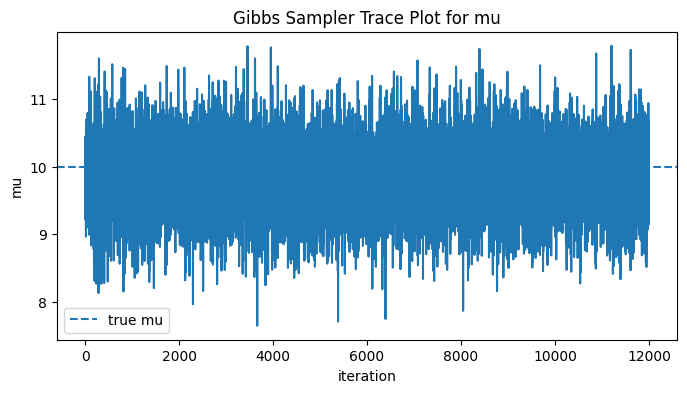

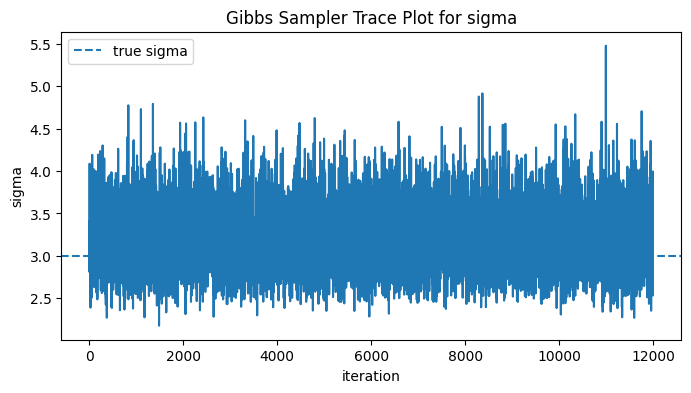

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(mu_chain)
plt.axhline(mu_true, linestyle="--", label="true mu")
plt.xlabel("iteration")
plt.ylabel("mu")
plt.title("Gibbs Sampler Trace Plot for mu")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.sqrt(sigma2_chain))
plt.axhline(sigma_true, linestyle="--", label="true sigma")
plt.xlabel("iteration")
plt.ylabel("sigma")
plt.title("Gibbs Sampler Trace Plot for sigma")
plt.legend()
plt.show()


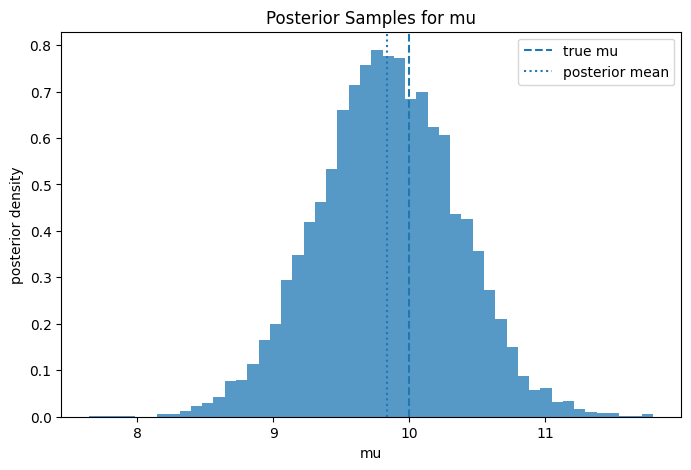

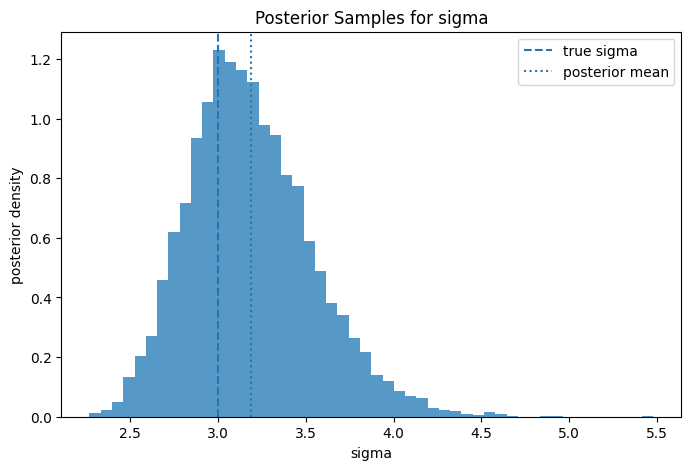

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(mu_post, bins=50, density=True, alpha=0.75)
plt.axvline(mu_true, linestyle="--", label="true mu")
plt.axvline(mu_post.mean(), linestyle=":", label="posterior mean")
plt.xlabel("mu")
plt.ylabel("posterior density")
plt.title("Posterior Samples for mu")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sigma_post, bins=50, density=True, alpha=0.75)
plt.axvline(sigma_true, linestyle="--", label="true sigma")
plt.axvline(sigma_post.mean(), linestyle=":", label="posterior mean")
plt.xlabel("sigma")
plt.ylabel("posterior density")
plt.title("Posterior Samples for sigma")
plt.legend()
plt.show()


### Interpretation

The trace plots should look like stable random fluctuations around a region, not a strong trend.  The posterior summaries should be close to the true values used to simulate the data, up to sampling variation.


# Section 19. ANOVA II: Factorial Designs, Contrasts, and Multiple Comparisons

One-way ANOVA compares means across one factor.  Two-way ANOVA compares means across two factors and can test whether the effect of one factor depends on the level of the other factor.

A common model is

$$
Y_{ijk}=\mu+\alpha_i+\beta_j+(\alpha\beta)_{ij}+\varepsilon_{ijk},
\qquad
\varepsilon_{ijk}\overset{iid}{\sim}N(0,\sigma^2).
$$

Here:

- $\alpha_i$ is the effect of factor A.
- $\beta_j$ is the effect of factor B.
- $(\alpha\beta)_{ij}$ is the interaction effect.


## Exercise 6. Simulate a two-way ANOVA dataset

Suppose a course wants to compare exam scores by:

- teaching method: Traditional, Flipped, AI-Tutor
- practice level: Low, High

The true means are:

| Method | Low Practice | High Practice |
|---|---:|---:|
| Traditional | 70 | 74 |
| Flipped | 74 | 81 |
| AI-Tutor | 78 | 88 |

The larger improvement for AI-Tutor at high practice suggests an interaction.

### Tasks

1. Simulate 18 students per cell.
2. Plot group means.
3. Fit a two-way ANOVA model with interaction.


In [14]:
np.random.seed(19)

methods = ["Traditional", "Flipped", "AI-Tutor"]
practice_levels = ["Low", "High"]
true_means = {
    ("Traditional", "Low"): 70,
    ("Traditional", "High"): 74,
    ("Flipped", "Low"): 74,
    ("Flipped", "High"): 81,
    ("AI-Tutor", "Low"): 78,
    ("AI-Tutor", "High"): 88,
}

rows = []
cell_n = 18
sigma = 5
for method in methods:
    for practice in practice_levels:
        mean = true_means[(method, practice)]
        scores = np.random.normal(mean, sigma, size=cell_n)
        for score in scores:
            rows.append({"method": method, "practice": practice, "score": score})

df = pd.DataFrame(rows)
df.head()


,method,practice,score
0,Traditional,Low,71.1050
1,Traditional,Low,68.2977
2,Traditional,Low,67.1113
3,Traditional,Low,67.9798
4,Traditional,Low,66.9836


In [15]:
cell_summary = df.groupby(["method", "practice"])["score"].agg(["mean", "std", "count"]).reset_index()
cell_summary


,method,practice,mean,std,count
0,AI-Tutor,High,86.7734,4.4006,18
1,AI-Tutor,Low,77.4322,4.6300,18
2,Flipped,High,80.8080,4.6584,18
3,Flipped,Low,74.6077,2.8203,18
4,Traditional,High,75.8521,5.0025,18
5,Traditional,Low,68.8055,4.1822,18


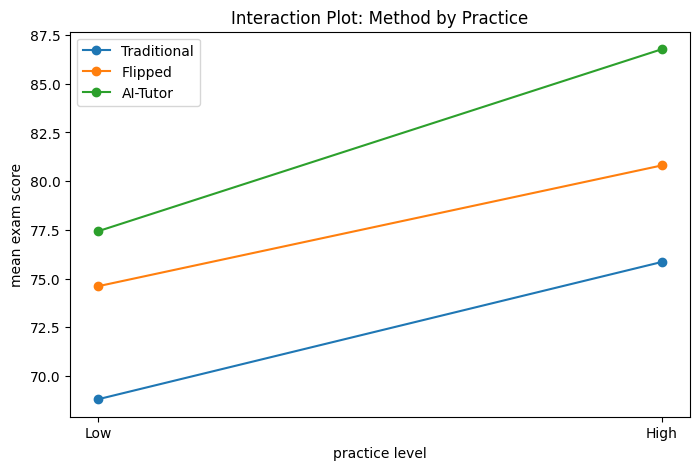

In [16]:
# Interaction plot using only matplotlib
summary_pivot = cell_summary.pivot(index="practice", columns="method", values="mean").loc[practice_levels]

plt.figure(figsize=(8, 5))
for method in methods:
    plt.plot(practice_levels, summary_pivot[method], marker="o", label=method)
plt.xlabel("practice level")
plt.ylabel("mean exam score")
plt.title("Interaction Plot: Method by Practice")
plt.legend()
plt.show()


In [17]:
# Fit two-way ANOVA with interaction
model_interaction = smf.ols("score ~ C(method) * C(practice)", data=df).fit()
anova_interaction = sm.stats.anova_lm(model_interaction, typ=2)
anova_interaction


,sum_sq,df,F,PR(>F)
C(method),1725.3724,2.0,45.8171,6.3462e-15
C(practice),1530.6514,1.0,81.2927,1.2197e-14
C(method):C(practice),47.5377,2.0,1.2624,2.8737e-01
Residual,1920.5475,102.0,NaN,NaN


### Interpretation

- A significant method effect means at least one method has a different mean score.
- A significant practice effect means high and low practice levels differ on average.
- A significant interaction means the effect of practice depends on the teaching method, or equivalently the method effect depends on practice level.

In this simulated example, we expect evidence for all three because the data were generated with main effects and an interaction.


## Exercise 7. Model comparison: with interaction vs. without interaction

Fit the additive model

$$
Y=\mu+\alpha_i+\beta_j+\varepsilon
$$

and compare it with the interaction model.

### Tasks

1. Fit the additive model.
2. Compare the two models using an F-test.
3. Interpret the result.


In [18]:
model_additive = smf.ols("score ~ C(method) + C(practice)", data=df).fit()

comparison = sm.stats.anova_lm(model_additive, model_interaction)
comparison


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,104.0,1968.0851,0.0,NaN,NaN,NaN
1,102.0,1920.5475,2.0,47.5377,1.2624,0.2874


### Interpretation

The model comparison tests whether adding the interaction terms significantly improves the model.  A small $p$-value supports the interaction model.


## Exercise 8. Linear contrast in a one-way ANOVA setting

Now focus only on students with high practice.  Compare AI-Tutor with the average of Traditional and Flipped:

$$
L=\mu_{AI}-\frac{1}{2}\mu_{Traditional}-\frac{1}{2}\mu_{Flipped}.
$$

### Tasks

1. Estimate the contrast.
2. Compute its standard error.
3. Construct a 95% confidence interval.
4. Test $H_0:L=0$.


In [19]:
high_df = df[df["practice"] == "High"].copy()

# Group means and sizes
means = high_df.groupby("method")["score"].mean().reindex(methods)
sizes = high_df.groupby("method")["score"].size().reindex(methods)

# Fit one-way ANOVA to estimate pooled MSE
oneway_model = smf.ols("score ~ C(method)", data=high_df).fit()
oneway_anova = sm.stats.anova_lm(oneway_model, typ=2)
MSE = oneway_anova.loc["Residual", "sum_sq"] / oneway_anova.loc["Residual", "df"]

# Contrast coefficients in order: Traditional, Flipped, AI-Tutor
c = np.array([-0.5, -0.5, 1.0])
L_hat = np.sum(c * means.values)
SE_L = np.sqrt(MSE * np.sum(c**2 / sizes.values))

df_error = oneway_anova.loc["Residual", "df"]
t_stat = L_hat / SE_L
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df_error))
crit = stats.t.ppf(0.975, df=df_error)
ci = (L_hat - crit*SE_L, L_hat + crit*SE_L)

pd.DataFrame({
    "quantity": ["contrast estimate", "SE", "t statistic", "df", "p-value", "CI low", "CI high"],
    "value": [L_hat, SE_L, t_stat, df_error, p_value, ci[0], ci[1]]
})


,quantity,value
0,contrast estimate,8.4433e+00
1,SE,1.3549e+00
2,t statistic,6.2315e+00
3,df,5.1000e+01
4,p-value,8.8830e-08
5,CI low,5.7232e+00
6,CI high,1.1163e+01


### Interpretation

If the confidence interval for $L$ is entirely above 0, then AI-Tutor has a higher mean score than the average of the other two methods among high-practice students.


## Exercise 9. Multiple comparisons using Tukey's HSD

ANOVA tells us whether some group means differ, but not exactly which pairs differ.  Tukey's HSD controls the family-wise error rate when comparing all pairs.

### Task

For the high-practice group, perform all pairwise comparisons among teaching methods.


In [20]:
tukey = pairwise_tukeyhsd(endog=high_df["score"], groups=high_df["method"], alpha=0.05)
print(tukey)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2   meandiff p-adj   lower    upper  reject
------------------------------------------------------------
AI-Tutor     Flipped  -5.9654 0.0011  -9.7422 -2.1886   True
AI-Tutor Traditional -10.9213    0.0 -14.6981 -7.1445   True
 Flipped Traditional   -4.956 0.0072  -8.7328 -1.1792   True
------------------------------------------------------------


### Interpretation

The column `reject` tells us whether to reject equality for that pair after Tukey adjustment.  This is more appropriate than doing many unadjusted pairwise $t$-tests.


## Exercise 10. Permutation ANOVA

The classical ANOVA $F$-test assumes normal errors and equal variances.  A permutation test gives a simulation-based reference distribution under the null hypothesis that group labels are exchangeable.

We use the high-practice data and test whether the three teaching methods have equal means.

### Tasks

1. Compute the observed one-way ANOVA $F$ statistic.
2. Randomly permute method labels many times.
3. Compare the observed statistic with the permutation distribution.


In [21]:
def one_way_F(data, group_col, y_col):
    groups = [g[y_col].values for _, g in data.groupby(group_col)]
    all_y = data[y_col].values
    grand_mean = all_y.mean()
    k = len(groups)
    n_total = len(all_y)
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(np.sum((g - g.mean())**2) for g in groups)
    ms_between = ss_between / (k - 1)
    ms_within = ss_within / (n_total - k)
    return ms_between / ms_within

F_obs = one_way_F(high_df, "method", "score")

B = 5000
F_perm = np.zeros(B)
permuted = high_df.copy()
for b in range(B):
    permuted["method"] = np.random.permutation(high_df["method"].values)
    F_perm[b] = one_way_F(permuted, "method", "score")

perm_p = np.mean(F_perm >= F_obs)

pd.DataFrame({
    "quantity": ["observed F", "permutation p-value"],
    "value": [F_obs, perm_p]
})


,quantity,value
0,observed F,24.4328
1,permutation p-value,0.0000


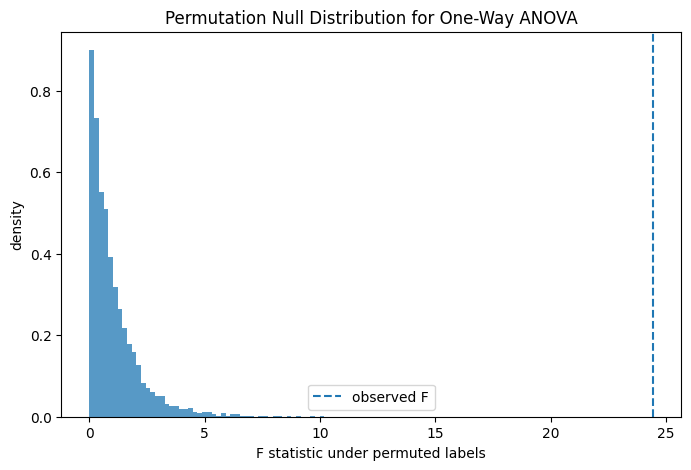

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(F_perm, bins=50, density=True, alpha=0.75)
plt.axvline(F_obs, linestyle="--", label="observed F")
plt.xlabel("F statistic under permuted labels")
plt.ylabel("density")
plt.title("Permutation Null Distribution for One-Way ANOVA")
plt.legend()
plt.show()


### Interpretation

The permutation $p$-value is the proportion of permuted datasets whose $F$ statistic is at least as large as the observed $F$ statistic.  If this value is small, the observed group separation is unlikely under random labels.


## Exercise 11. Checking ANOVA assumptions

Classical ANOVA relies on:

1. independent observations,
2. approximately normal residuals,
3. approximately equal variances across groups.

### Tasks

1. Make a residual plot.
2. Make a Q-Q plot.
3. Use Levene's test for equality of variances.


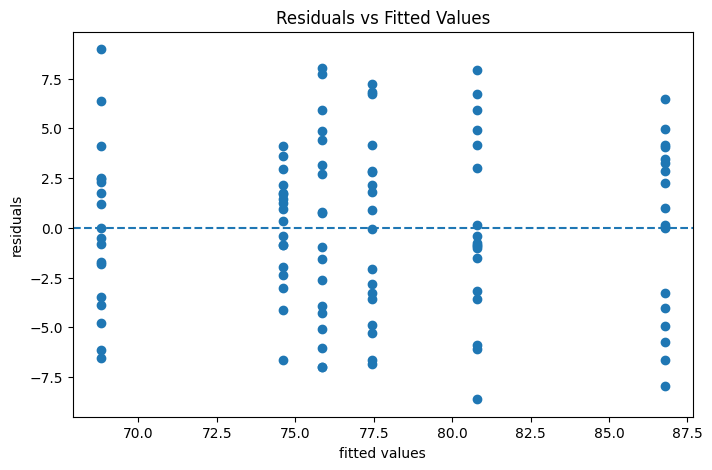

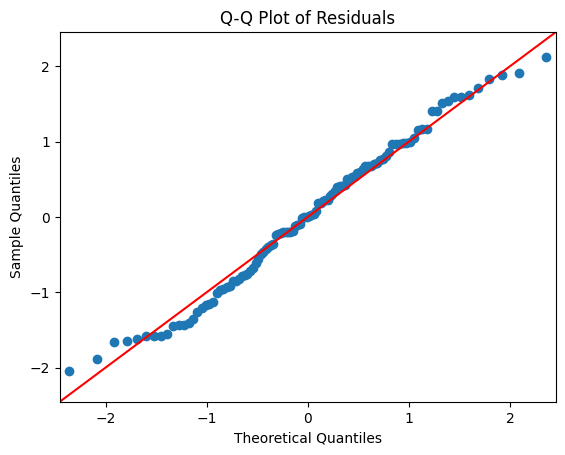

,quantity,value
0,Levene statistic,1.5160
1,Levene p-value,0.1914


In [23]:
resid = model_interaction.resid
fitted = model_interaction.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid)
plt.axhline(0, linestyle="--")
plt.xlabel("fitted values")
plt.ylabel("residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Levene test across the six cells
cell_groups = [g["score"].values for _, g in df.groupby(["method", "practice"])]
levene_stat, levene_p = stats.levene(*cell_groups)

pd.DataFrame({
    "quantity": ["Levene statistic", "Levene p-value"],
    "value": [levene_stat, levene_p]
})


### Interpretation

- The residual plot should show no strong pattern.
- The Q-Q plot should be roughly linear if residuals are close to normal.
- A small Levene $p$-value suggests unequal variances.

Small deviations are common in real data.  Large deviations may suggest transforming the response, using robust methods, or using a permutation approach.


## Exercise 12. Mini-project: Bayesian comparison of three treatment means

We now combine Section 18 and Section 19 ideas.  Consider the high-practice data again.  We estimate each group mean using a Bayesian normal model with known common standard deviation $\sigma=5$ and prior

$$
\mu_j \sim N(75,10^2),
$$

independently for each method.

### Tasks

1. Compute the posterior distribution for each group mean.
2. Simulate posterior samples of the three group means.
3. Estimate $P(\mu_{AI} > \mu_{Flipped} > \mu_{Traditional}\mid \text{data})$.
4. Estimate $P(\mu_{AI} > \mu_{Traditional}+5\mid \text{data})$.


In [24]:
known_sigma = 5
prior_mean = 75
prior_sd = 10

posterior_params = {}
for method in methods:
    y = high_df.loc[high_df["method"] == method, "score"].values
    pm, psd, lo, hi = normal_mean_posterior_known_sigma(y, known_sigma, prior_mean, prior_sd)
    posterior_params[method] = (pm, psd)

bayes_summary = pd.DataFrame([
    {
        "method": method,
        "posterior_mean": posterior_params[method][0],
        "posterior_sd": posterior_params[method][1],
        "CI_low": stats.norm.ppf(0.025, posterior_params[method][0], posterior_params[method][1]),
        "CI_high": stats.norm.ppf(0.975, posterior_params[method][0], posterior_params[method][1]),
    }
    for method in methods
])
bayes_summary


,method,posterior_mean,posterior_sd,CI_low,CI_high
0,Traditional,75.8404,1.1704,73.5464,78.1343
1,Flipped,80.7284,1.1704,78.4345,83.0224
2,AI-Tutor,86.6121,1.1704,84.3181,88.9061


In [25]:
M = 200_000
posterior_draws = {}
for method in methods:
    pm, psd = posterior_params[method]
    posterior_draws[method] = np.random.normal(pm, psd, size=M)

prob_order = np.mean(
    (posterior_draws["AI-Tutor"] > posterior_draws["Flipped"]) &
    (posterior_draws["Flipped"] > posterior_draws["Traditional"])
)

prob_ai_5_better = np.mean(posterior_draws["AI-Tutor"] > posterior_draws["Traditional"] + 5)

pd.DataFrame({
    "posterior_probability": [
        "P(AI-Tutor > Flipped > Traditional | data)",
        "P(AI-Tutor > Traditional + 5 | data)",
    ],
    "value": [prob_order, prob_ai_5_better]
})


,posterior_probability,value
0,P(AI-Tutor > Flipped > Traditional | data),0.9981
1,P(AI-Tutor > Traditional + 5 | data),0.9997


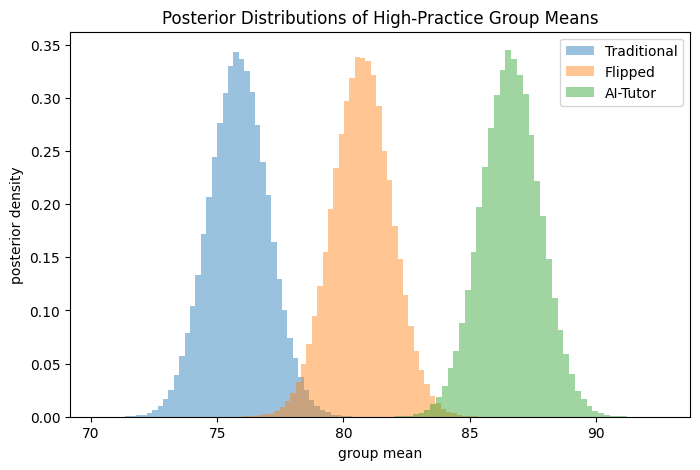

In [26]:
plt.figure(figsize=(8, 5))
for method in methods:
    plt.hist(posterior_draws[method], bins=50, density=True, alpha=0.45, label=method)
plt.xlabel("group mean")
plt.ylabel("posterior density")
plt.title("Posterior Distributions of High-Practice Group Means")
plt.legend()
plt.show()


### Interpretation

This Bayesian analysis gives direct probability statements about the group means.  It complements ANOVA: ANOVA tests whether group means differ; Bayesian posterior simulation can answer questions such as whether one treatment is best or whether a difference is practically meaningful.


# Final summary

In this lab, we practiced the following Section 18–19 skills:

1. Bayesian updating for normal, binomial, and Poisson models.
2. Prior sensitivity analysis.
3. Posterior predictive simulation.
4. Gibbs sampling for a normal model with unknown mean and variance.
5. Two-way ANOVA with interaction.
6. Model comparison using an F-test.
7. Linear contrasts and multiple comparisons.
8. Permutation ANOVA.
9. Bayesian comparison of treatment means.

These tools connect the final part of statistical theory with practical data analysis workflows.
